In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [1]:
df = pd.read_csv('Heart_Disease.csv')
df

NameError: name 'pd' is not defined

In [ ]:
info = df.info()

In [5]:
des= df.describe()
des

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [6]:
print("Shape of Dataset:")
shape= df.shape
shape

Shape of Dataset:


(1025, 14)

In [7]:
print("columns:")
col=df.columns
col

columns:


Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [11]:
print('Missing Values:')
df.isnull().sum()

Missing Values:


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Missing Values through Visulaization:


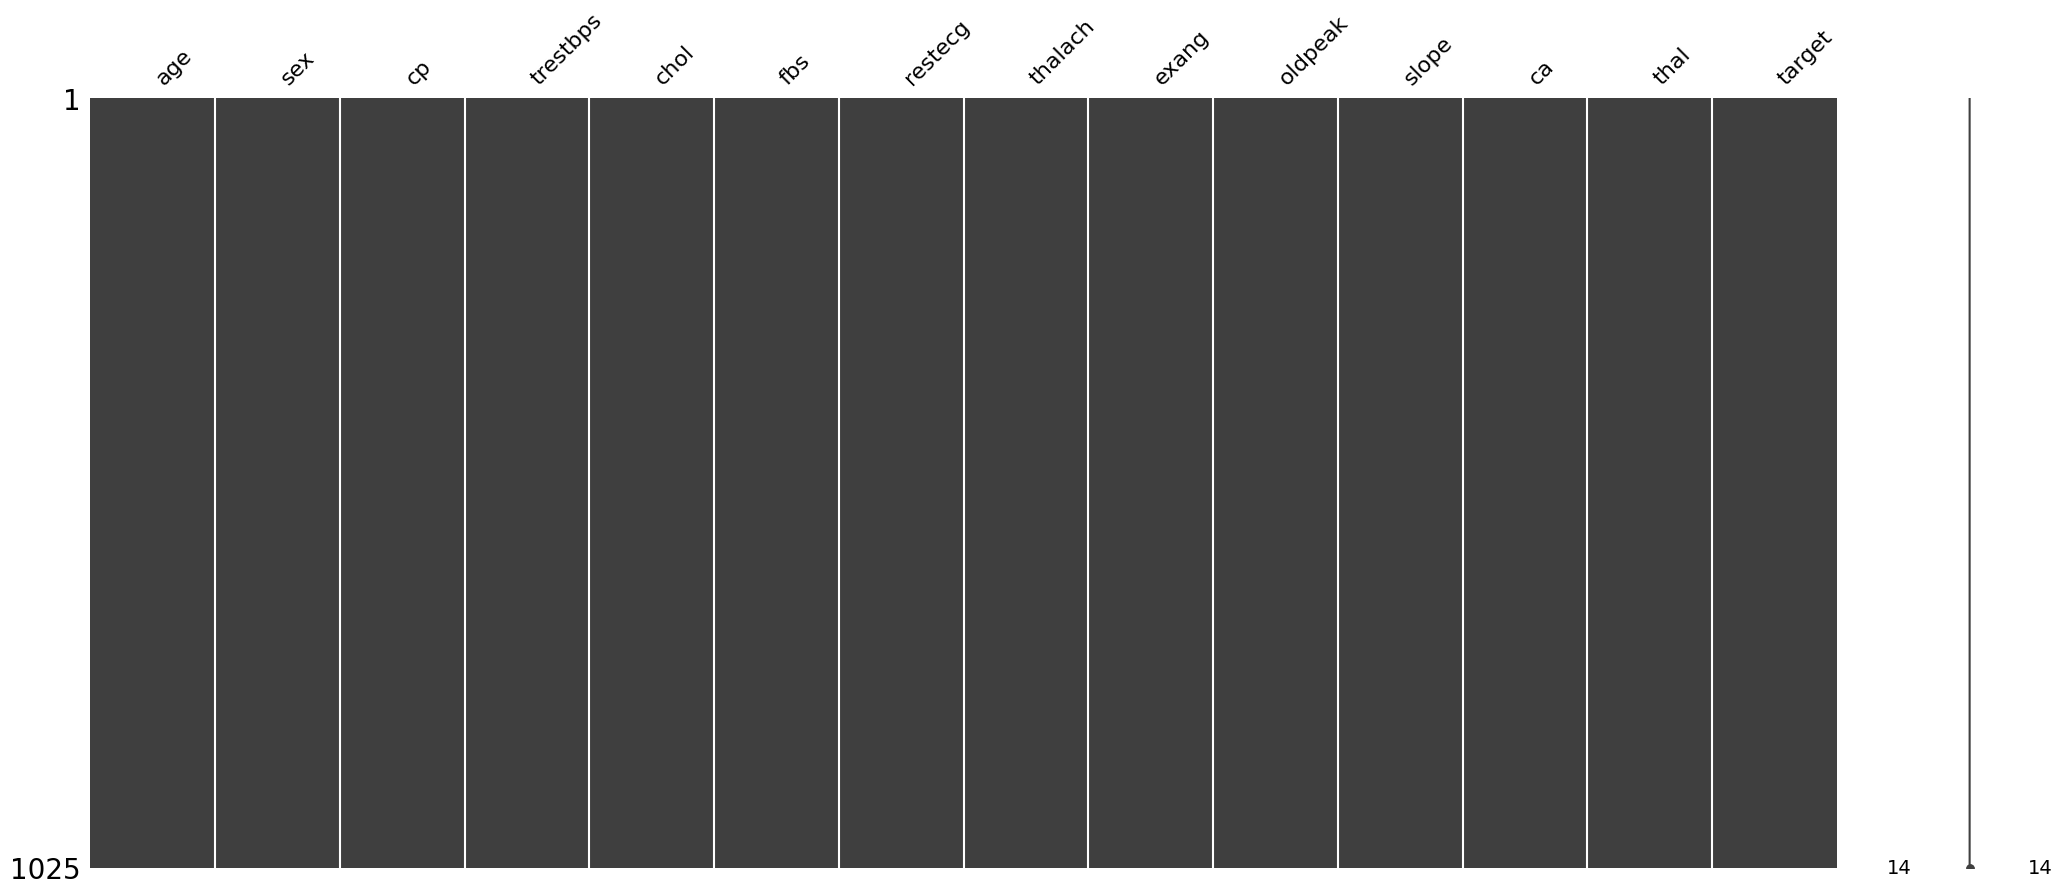

In [8]:
import missingno as msno
print("Missing Values through Visulaization:")
msno.matrix(df)
plt.show()

In [1]:
import pandas as pd
df = pd.read_csv("Heart_Disease.csv")
columns = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

for column in columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(f"\nOutliers in {column}:")
    print(outliers[[column]])


Outliers in age:
Empty DataFrame
Columns: [age]
Index: []

Outliers in trestbps:
     trestbps
29        180
47        178
87        174
137       180
151       192
175       200
229       178
246       192
257       180
294       200
326       192
343       172
396       180
436       174
452       178
496       180
508       200
509       180
528       178
609       180
624       178
636       174
679       180
688       200
837       172
891       180
896       178
944       178
971       172
986       180

Outliers in chol:
     chol
123   417
158   564
179   409
192   564
255   394
450   407
464   564
481   407
542   394
578   394
641   409
665   417
685   407
889   407
958   417
996   409

Outliers in thalach:
     thalach
267       71
296       71
378       71
559       71

Outliers in oldpeak:
     oldpeak
54       5.6
55       5.6
69       6.2
393      6.2
526      6.2
613      5.6
833      5.6


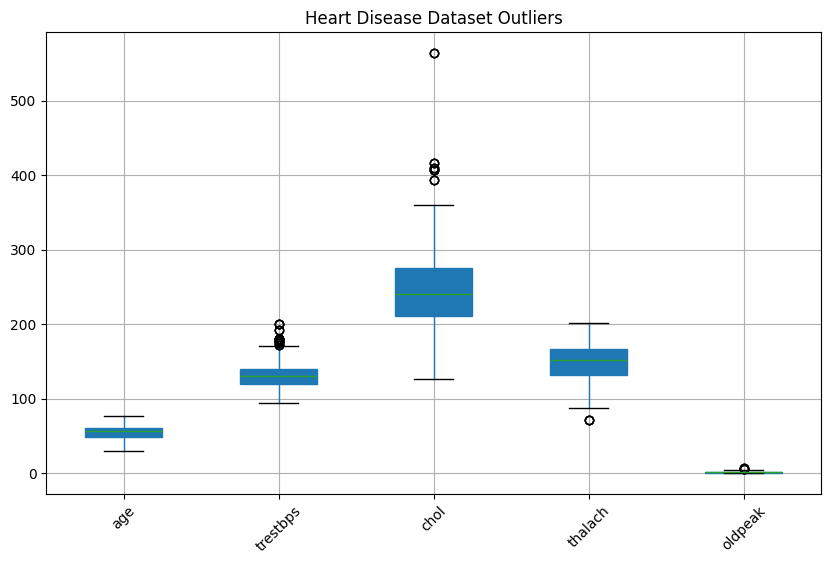

In [4]:
import matplotlib.pyplot as plt

# Create boxplot
box = df[columns].boxplot(
    figsize=(10,6),
    patch_artist=True
)

# Colors for each box
colors = ['red', 'blue', 'brown', 'yellow', 'black']

# Apply colors
for patch, color in zip(box.artists, colors):
    patch.set_facecolor(color)

# Title and labels
plt.title("Heart Disease Dataset Outliers")
plt.xticks(rotation=45)

# Show plot
plt.show()

Original Dataset Shape: (1025, 14)
Cleaned Dataset Shape: (964, 14)

Outliers removed successfully!
Cleaned dataset saved as cleaned_heart.csv


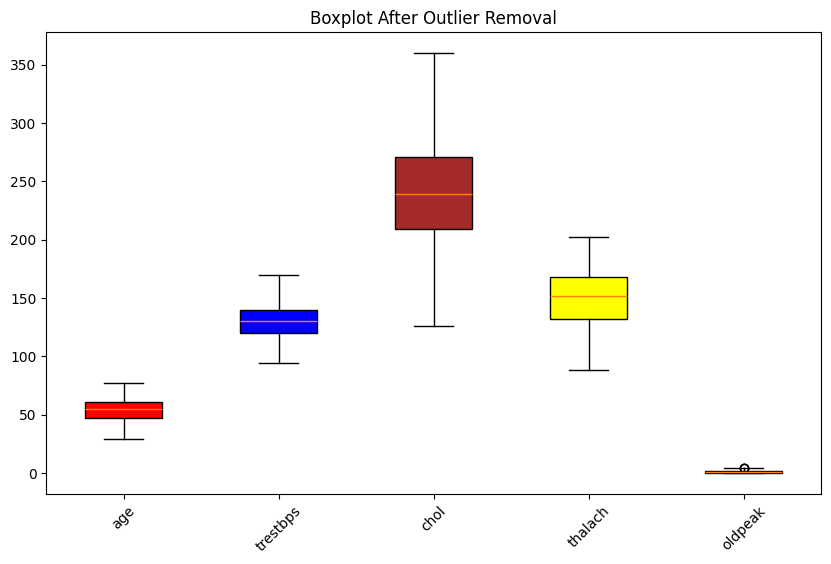

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("Heart_Disease.csv")

# Columns for outlier removal
columns = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Copy dataset
clean_df = df.copy()

# Remove outliers using IQR
for column in columns:

    # Calculate Q1 and Q3
    Q1 = clean_df[column].quantile(0.25)
    Q3 = clean_df[column].quantile(0.75)

    # Calculate IQR
    IQR = Q3 - Q1

    # Calculate bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Remove outliers
    clean_df = clean_df[
        (clean_df[column] >= lower_bound) &
        (clean_df[column] <= upper_bound)
    ]

# Shapes before and after cleaning
print("Original Dataset Shape:", df.shape)
print("Cleaned Dataset Shape:", clean_df.shape)

# Save cleaned dataset
clean_df.to_csv("cleaned_heart.csv", index=False)

print("\nOutliers removed successfully!")
print("Cleaned dataset saved as cleaned_heart.csv")

# -----------------------------
# Boxplot AFTER outlier removal
# -----------------------------

# Close previous empty figures
plt.close('all')

# Create figure
fig, ax = plt.subplots(figsize=(10,6))

# Create boxplot
bp = ax.boxplot(
    [clean_df[col] for col in columns],
    patch_artist=True,
    tick_labels=columns
)

# Colors
colors = ['red', 'blue', 'brown', 'yellow', 'black']

# Apply colors
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# Title
ax.set_title("Boxplot After Outlier Removal")

# Rotate labels
plt.xticks(rotation=45)

# Show graph
plt.show()

EXPLORATORY DATA ANALYSIS

🎯 Target Distribution (Heart Disease):
   No Disease (0): 499 (48.7%)
   Disease (1): 526 (51.3%)

📊 Feature Analysis by Target:
   age: Disease=52.41, No Disease=56.57
   trestbps: Disease=129.25, No Disease=134.11
   chol: Disease=240.98, No Disease=251.29
   thalach: Disease=158.59, No Disease=139.13
   oldpeak: Disease=0.57, No Disease=1.60


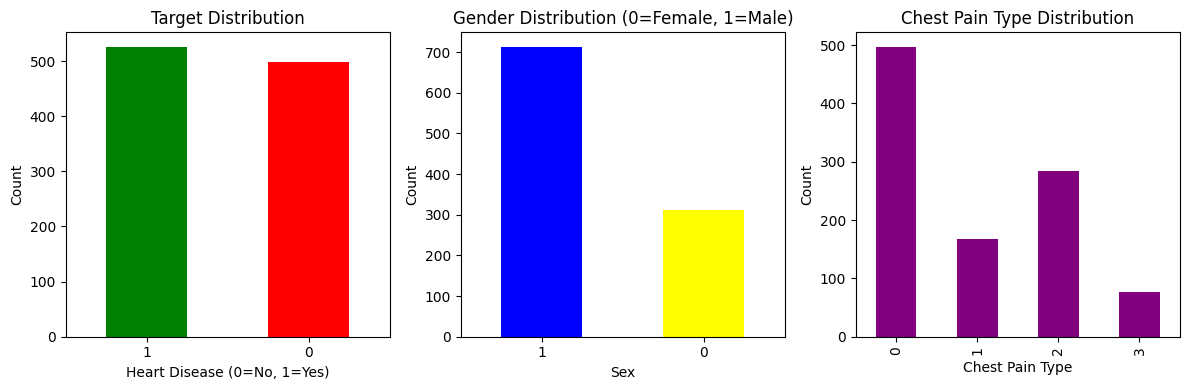

In [18]:
print("="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

# Target distribution
print(f"\n🎯 Target Distribution (Heart Disease):")
target_counts = df['target'].value_counts()
print(f"   No Disease (0): {target_counts[0]} ({target_counts[0]/len(df)*100:.1f}%)")
print(f"   Disease (1): {target_counts[1]} ({target_counts[1]/len(df)*100:.1f}%)")

# Feature distributions by target
print(f"\n📊 Feature Analysis by Target:")
features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
for feature in features:
    disease_mean = df[df['target']==1][feature].mean()
    no_disease_mean = df[df['target']==0][feature].mean()
    print(f"   {feature}: Disease={disease_mean:.2f}, No Disease={no_disease_mean:.2f}")
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
df['target'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Target Distribution')
plt.xlabel('Heart Disease (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.subplot(1, 3, 2)
df['sex'].value_counts().plot(kind='bar', color=['blue', 'yellow'])
plt.title('Gender Distribution (0=Female, 1=Male)')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.subplot(1, 3, 3)
df['cp'].value_counts().sort_index().plot(kind='bar', color='purple')
plt.title('Chest Pain Type Distribution')
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150)
plt.show()


========== HEART DISEASE AI SYSTEM ==========


Enter patient Name: Haseeb
Enter Age:  16
Enter Chest Pain Level (0-4):  0
Enter Cholesterol:  200
Enter Max Heart Rate:  70
Enter OldPeak Value:  0
Enter Blood Pressure:  70



========== RESULTS ==========

Expert System Diagnosis:
LOW RISK

Propositional Logic:
NO HEART DISEASE

Constraint Satisfaction:
Patient Risk Detected

Simple Reflex Agent:
LOW RISK

Model Based Agent:

Stored Memory:
{'Patient_ID': 8, 'Name': 'Haseeb', 'Date': datetime.datetime(2026, 5, 30, 12, 53, 39, 461710), 'Age': 16, 'ChestPain': 0, 'Cholesterol': 200, 'HeartRate': 70, 'OldPeak': 0.0, 'BloodPressure': 70, 'Diagnosis': 'LOW RISK'}

Goal Based Agent:
Healthy

Utility Based Agent:
Best Treatment: Exercise

========== BFS ==========

BFS Traversal:
ChestPain
HighBP
HighCholesterol
HeartDisease

========== DFS ==========
ChestPain
HighBP
HeartDisease
HighCholesterol

========== A* SEARCH ==========

A* Search:
Visiting: Start
Visiting: ChestPain
Visiting: HighBP
Visiting: HeartDisease
Goal Reached

========== COMPLETE PATIENT HISTORY ==========
   Patient_ID              Name                        Date  Age  ChestPain  \
0           1           Hemayat  2026-05-13 19:12:11.846752  

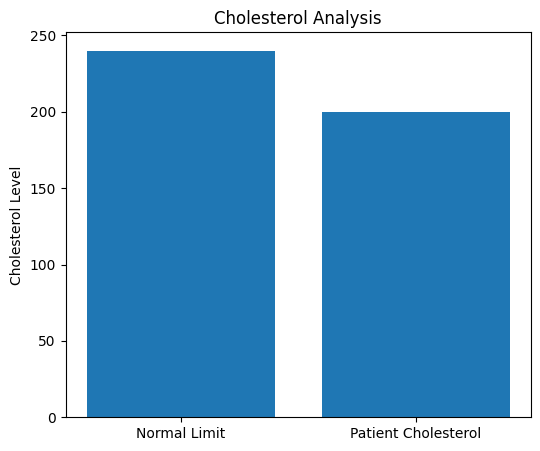

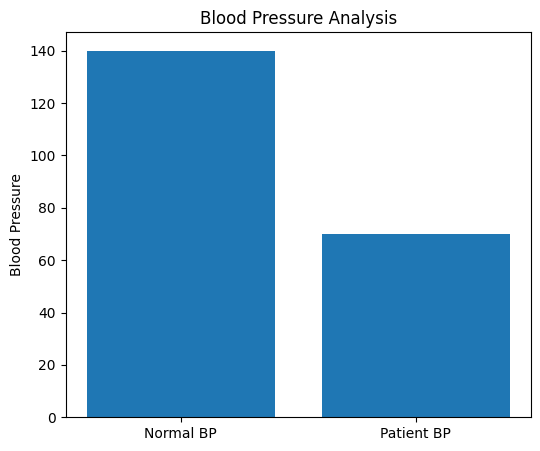

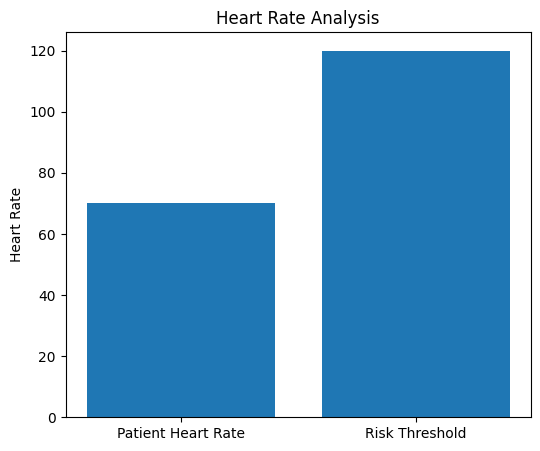

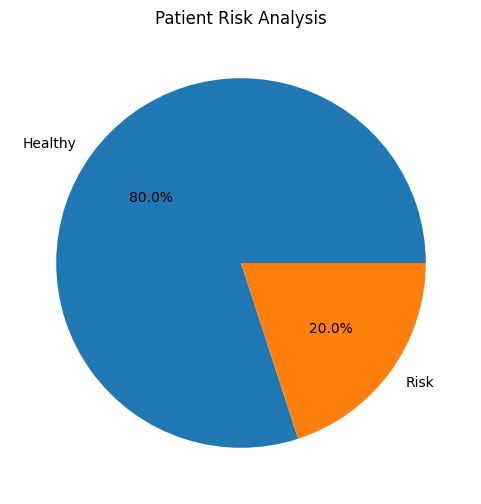

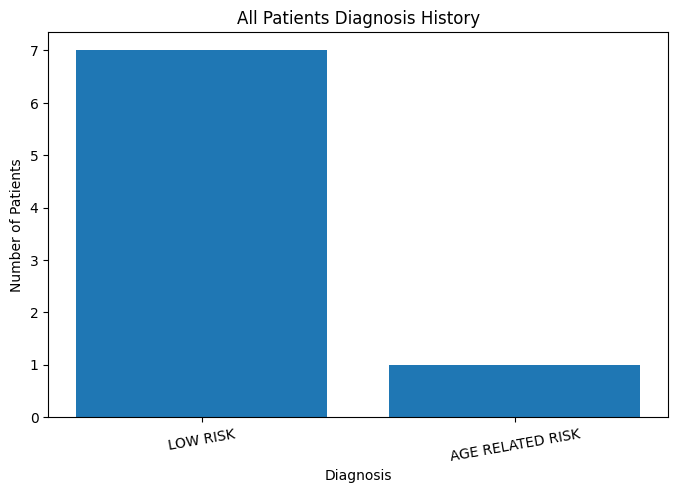

In [1]:
# ==========================================================
# ADVANCED HEART DISEASE AI EXPERT SYSTEM
# WITH PATIENT HISTORY STORAGE (NO DATABASE)
# ==========================================================

import pandas as pd
import os
import random
from collections import deque
import heapq
from datetime import datetime

# ==========================================================
# CREATE HISTORY FILE
# ==========================================================

history_file = "patient_history.csv"

if not os.path.exists(history_file):

    history_df = pd.DataFrame(columns=[
        "Patient_ID",
        "Name",
        "Date",
        "Age",
        "ChestPain",
        "Cholesterol",
        "HeartRate",
        "OldPeak",
        "BloodPressure",
        "Diagnosis"
    ])

    history_df.to_csv(history_file, index=False)

# ==========================================================
# BFS GRAPH SEARCH
# ==========================================================

graph = {
    "ChestPain": ["HighBP", "HighCholesterol"],
    "HighBP": ["HeartDisease"],
    "HighCholesterol": ["HeartDisease"],
    "HeartDisease": []
}

def bfs(graph, start):

    visited = set()
    queue = deque([start])

    print("\nBFS Traversal:")

    while queue:

        node = queue.popleft()

        if node not in visited:

            print(node)

            visited.add(node)

            for neighbor in graph[node]:
                queue.append(neighbor)

# ==========================================================
# DFS GRAPH SEARCH
# ==========================================================

def dfs(graph, node, visited=None):

    if visited is None:
        visited = set()

    if node not in visited:

        print(node)

        visited.add(node)

        for neighbor in graph[node]:
            dfs(graph, neighbor, visited)

# ==========================================================
# A* SEARCH
# ==========================================================

medical_graph = {
    "Start": [("ChestPain", 1), ("Fatigue", 3)],
    "ChestPain": [("HighBP", 2)],
    "Fatigue": [("HighCholesterol", 2)],
    "HighBP": [("HeartDisease", 2)],
    "HighCholesterol": [("HeartDisease", 1)],
    "HeartDisease": []
}

heuristic = {
    "Start": 6,
    "ChestPain": 4,
    "Fatigue": 5,
    "HighBP": 2,
    "HighCholesterol": 1,
    "HeartDisease": 0
}

def a_star(start, goal):

    pq = []
    heapq.heappush(pq, (0, start))

    cost = {start: 0}

    print("\nA* Search:")

    while pq:

        current = heapq.heappop(pq)[1]

        print("Visiting:", current)

        if current == goal:
            print("Goal Reached")
            return

        for neighbor, weight in medical_graph[current]:

            new_cost = cost[current] + weight

            if neighbor not in cost or new_cost < cost[neighbor]:

                cost[neighbor] = new_cost
                priority = new_cost + heuristic[neighbor]

                heapq.heappush(pq, (priority, neighbor))

# ==========================================================
# SIMPLE REFLEX AGENT
# ==========================================================

class SimpleReflexAgent:

    def diagnose(self, chol):

        if chol > 240:
            return "HIGH RISK"

        return "LOW RISK"

# ==========================================================
# MODEL BASED AGENT
# ==========================================================

class ModelBasedAgent:

    def __init__(self):

        self.memory = []

    def update_memory(self, patient):

        self.memory.append(patient)

    def show_memory(self):

        print("\nStored Memory:")

        for p in self.memory:
            print(p)

# ==========================================================
# GOAL BASED AGENT
# ==========================================================

class GoalBasedAgent:

    def goal(self, chol, bp):

        if chol > 240:
            return "Reduce Cholesterol"

        elif bp > 140:
            return "Reduce Blood Pressure"

        return "Healthy"

# ==========================================================
# UTILITY BASED AGENT
# ==========================================================

class UtilityBasedAgent:

    def best_treatment(self):

        utilities = {
            "Exercise": 95,
            "Healthy Diet": 90,
            "Medication": 70,
            "Surgery": 50
        }

        best = max(utilities, key=utilities.get)

        return best





# ==========================================================
# CSP
# ==========================================================

def check_constraints(chol, bp, hr):

    if chol < 240 and bp < 140 and hr > 120:
        return "Constraints Satisfied"

    return "Patient Risk Detected"
# ==========================================================
# PROPOSITIONAL LOGIC
# ==========================================================

def propositional_logic(chol, cp, hr):

    P = chol > 240
    Q = cp > 2
    R = hr < 120

    if P and Q and R:
        return "HEART DISEASE DETECTED"

    return "NO HEART DISEASE"

# ==========================================================
# RULE BASED EXPERT SYSTEM
# ==========================================================

def expert_system(age, cp, chol, hr, oldpeak, bp):

    # HIGH RISK
    if cp > 2 and chol > 240 and hr < 120 and oldpeak > 2:
        return "HIGH RISK HEART DISEASE"

    # MEDIUM RISK
    elif bp > 140 and chol > 220:
        return "MEDIUM RISK"

    # AGE RISK
    elif age > 60:
        return "AGE RELATED RISK"

    else:
        return "LOW RISK"

# ==========================================================
# FUTURE PATIENT INPUT
# ==========================================================

print("\n========== HEART DISEASE AI SYSTEM ==========")

Name = input("Enter patient Name:")
age = int(input("Enter Age: "))
cp = int(input("Enter Chest Pain Level (0-4): "))
chol = int(input("Enter Cholesterol: "))
hr = int(input("Enter Max Heart Rate: "))
oldpeak = float(input("Enter OldPeak Value: "))
bp = int(input("Enter Blood Pressure: "))

# ==========================================================
# DIAGNOSIS
# ==========================================================

diagnosis = expert_system(age, cp, chol, hr, oldpeak, bp)

# ==========================================================
# STORE PATIENT RECORD
# ==========================================================

history_df = pd.read_csv(history_file)

patient_id = len(history_df) + 1

current_date = datetime.now()

new_patient = {
    "Patient_ID": patient_id,
    "Name": Name,
    "Date": current_date,
    "Age": age,
    "ChestPain": cp,
    "Cholesterol": chol,
    "HeartRate": hr,
    "OldPeak": oldpeak,
    "BloodPressure": bp,
    "Diagnosis": diagnosis
}

new_row = pd.DataFrame([new_patient])

if history_df.empty:

    history_df = new_row

else:

    history_df = pd.concat(
        [history_df, new_row],
        ignore_index=True
    )

# SAVE UPDATED DATA
history_df.to_csv(history_file, index=False)

# ==========================================================
# DISPLAY RESULTS
# ==========================================================

print("\n========== RESULTS ==========")

print("\nExpert System Diagnosis:")
print(diagnosis)

print("\nPropositional Logic:")
print(propositional_logic(chol, cp, hr))

print("\nConstraint Satisfaction:")
print(check_constraints(chol, bp, hr))

# ==========================================================
# AI AGENTS
# ==========================================================

reflex = SimpleReflexAgent()

print("\nSimple Reflex Agent:")
print(reflex.diagnose(chol))

model_agent = ModelBasedAgent()

model_agent.update_memory(new_patient)

print("\nModel Based Agent:")
model_agent.show_memory()

goal_agent = GoalBasedAgent()

print("\nGoal Based Agent:")
print(goal_agent.goal(chol, bp))

utility_agent = UtilityBasedAgent()

print("\nUtility Based Agent:")
print("Best Treatment:", utility_agent.best_treatment())

# ==========================================================
# BFS DFS A*
# ==========================================================

print("\n========== BFS ==========")

bfs(graph, "ChestPain")

print("\n========== DFS ==========")

dfs(graph, "ChestPain")

print("\n========== A* SEARCH ==========")

a_star("Start", "HeartDisease")

# ==========================================================
# VIEW COMPLETE HISTORY
# ==========================================================

print("\n========== COMPLETE PATIENT HISTORY ==========")

all_history = pd.read_csv(history_file)

print(all_history)
# ==========================================================
# VISUALIZATION GRAPHS
# ==========================================================

import matplotlib.pyplot as plt

# ----------------------------------------------------------
# GRAPH 1 - CHOLESTEROL ANALYSIS
# ----------------------------------------------------------

plt.figure(figsize=(6,5))

if chol > 240:
    values = [chol, 240]
    labels = ['Patient Cholesterol', 'Normal Limit']
else:
    values = [240, chol]
    labels = ['Normal Limit', 'Patient Cholesterol']

plt.bar(labels, values)

plt.title('Cholesterol Analysis')
plt.ylabel('Cholesterol Level')

plt.show()

# ----------------------------------------------------------
# GRAPH 2 - BLOOD PRESSURE ANALYSIS
# ----------------------------------------------------------

plt.figure(figsize=(6,5))

if bp > 140:
    values = [bp, 140]
    labels = ['Patient BP', 'Normal BP']
else:
    values = [140, bp]
    labels = ['Normal BP', 'Patient BP']

plt.bar(labels, values)

plt.title('Blood Pressure Analysis')
plt.ylabel('Blood Pressure')

plt.show()

# ----------------------------------------------------------
# GRAPH 3 - HEART RATE ANALYSIS
# ----------------------------------------------------------

plt.figure(figsize=(6,5))

values = [hr, 120]
labels = ['Patient Heart Rate', 'Risk Threshold']

plt.bar(labels, values)

plt.title('Heart Rate Analysis')
plt.ylabel('Heart Rate')

plt.show()

# ----------------------------------------------------------
# GRAPH 4 - PATIENT RISK PIE CHART
# ----------------------------------------------------------

plt.figure(figsize=(6,6))

if diagnosis == "LOW RISK":

    sizes = [80, 20]
    labels = ['Healthy', 'Risk']

elif diagnosis == "MEDIUM RISK":

    sizes = [50, 50]
    labels = ['Healthy', 'Risk']

else:

    sizes = [20, 80]
    labels = ['Healthy', 'Risk']

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%'
)

plt.title('Patient Risk Analysis')

plt.show()

# ----------------------------------------------------------
# GRAPH 5 - COMPLETE HISTORY ANALYSIS
# ----------------------------------------------------------

risk_counts = all_history['Diagnosis'].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
    risk_counts.index,
    risk_counts.values
)

plt.title('All Patients Diagnosis History')
plt.xlabel('Diagnosis')
plt.ylabel('Number of Patients')

plt.xticks(rotation=10)

plt.show()


Dataset Shape: (964, 14)

Selected Features:
Index(['sex', 'cp', 'restecg', 'exang', 'oldpeak', 'thal'], dtype='object')

Accuracy: 0.8134715025906736

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.83      0.80        89
           1       0.85      0.80      0.82       104

    accuracy                           0.81       193
   macro avg       0.81      0.81      0.81       193
weighted avg       0.82      0.81      0.81       193


Confusion Matrix:

[[74 15]
 [21 83]]


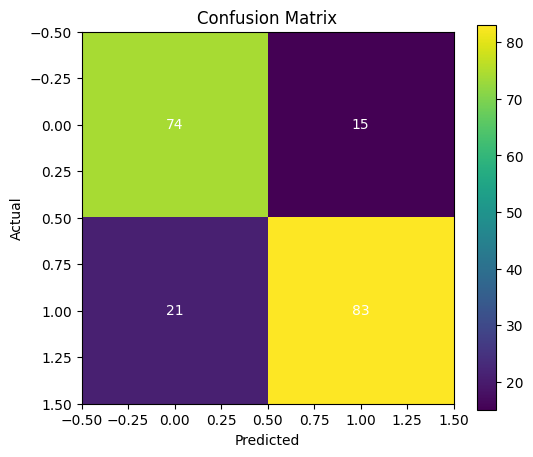

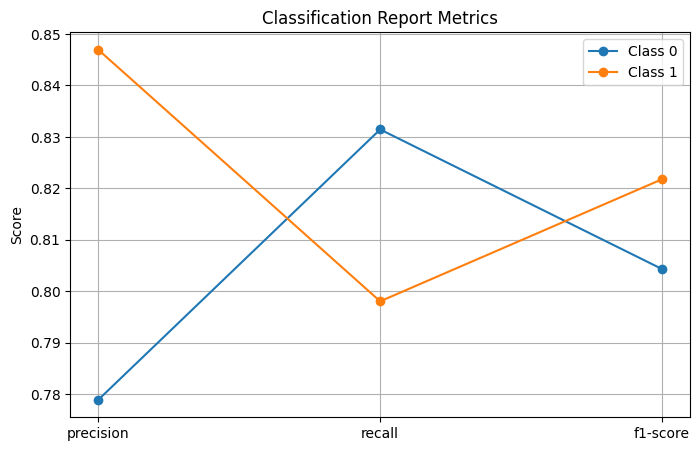

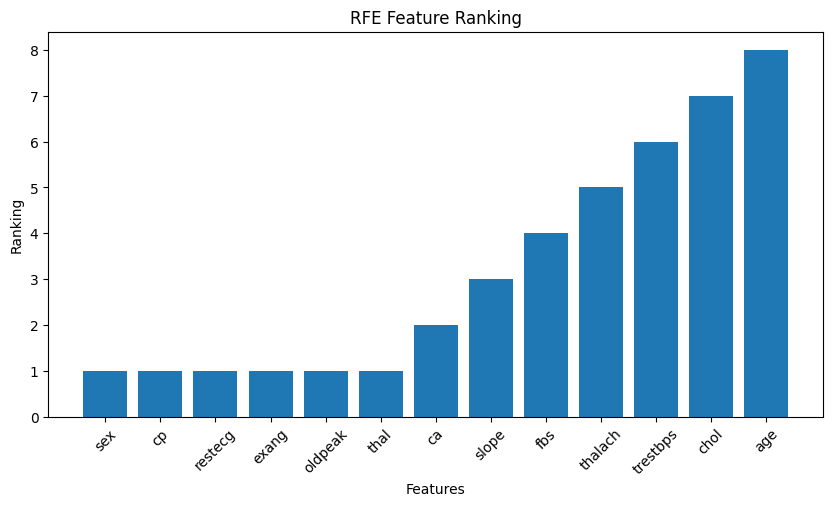


Prediction for First Patient: [0]
No Heart Disease


In [23]:
# ==========================================================
# HEART DISEASE PREDICTION SYSTEM
# USING:
# - RFE FEATURE SELECTION
# - LOGISTIC REGRESSION
# - STANDARD SCALER
# - CLASSIFICATION REPORT GRAPHS
# ==========================================================

# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ==========================================================
# LOAD CLEANED DATASET
# ==========================================================

df = pd.read_csv("cleaned_heart.csv")

print("Dataset Shape:", df.shape)

# ==========================================================
# FEATURES AND TARGET
# ==========================================================

X = df.drop("target", axis=1)
y = df["target"]

# ==========================================================
# FEATURE SELECTION USING RFE
# ==========================================================

# Base model
base_model = LogisticRegression(max_iter=5000)

# RFE
rfe = RFE(
    estimator=base_model,
    n_features_to_select=6
)

# Fit RFE
rfe.fit(X, y)

# Selected features
selected_features = X.columns[rfe.support_]

print("\nSelected Features:")
print(selected_features)

# Use selected features only
X_selected = X[selected_features]

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=60
)

# ==========================================================
# CREATE MODEL PIPELINE
# ==========================================================

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=5000,
        solver='liblinear'
    )
)

# ==========================================================
# TRAIN MODEL
# ==========================================================

model.fit(X_train, y_train)

# ==========================================================
# PREDICTIONS
# ==========================================================

y_pred = model.predict(X_test)

# ==========================================================
# ACCURACY
# ==========================================================

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)

# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

# Convert report into dictionary
report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n")
print(cm)

# ==========================================================
# GRAPH 1 - CONFUSION MATRIX
# ==========================================================

plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

# Add values inside matrix
for i in range(len(cm)):
    for j in range(len(cm[0])):

        plt.text(
            j,
            i,
            cm[i][j],
            ha='center',
            va='center',
            color='white'
        )

plt.show()

# ==========================================================
# GRAPH 2 - CLASSIFICATION REPORT METRICS
# ==========================================================

metrics = ['precision', 'recall', 'f1-score']

# Class 0 metrics
class_0 = [
    report['0']['precision'],
    report['0']['recall'],
    report['0']['f1-score']
]

# Class 1 metrics
class_1 = [
    report['1']['precision'],
    report['1']['recall'],
    report['1']['f1-score']
]

# X positions
x = range(len(metrics))

plt.figure(figsize=(8,5))

# Plot class 0
plt.plot(
    x,
    class_0,
    marker='o',
    label='Class 0'
)

# Plot class 1
plt.plot(
    x,
    class_1,
    marker='o',
    label='Class 1'
)

# Labels
plt.xticks(x, metrics)

plt.ylabel("Score")

plt.title("Classification Report Metrics")

plt.legend()

plt.grid(True)

plt.show()

# ==========================================================
# GRAPH 3 - FEATURE RANKING
# ==========================================================

ranking = pd.DataFrame({
    'Feature': X.columns,
    'Ranking': rfe.ranking_
})

ranking = ranking.sort_values(by='Ranking')

plt.figure(figsize=(10,5))

plt.bar(
    ranking['Feature'],
    ranking['Ranking']
)

plt.title("RFE Feature Ranking")

plt.xlabel("Features")

plt.ylabel("Ranking")

plt.xticks(rotation=45)

plt.show()

# ==========================================================
# SAMPLE PREDICTION
# ==========================================================

sample = X_selected.iloc[0:1]

prediction = model.predict(sample)

print("\nPrediction for First Patient:", prediction)

if prediction[0] == 1:
    print("Heart Disease Detected")
else:
    print("No Heart Disease")

Dataset Shape: (964, 14)

========== PATIENT GROUPING ==========
Cluster
1    419
2    313
0    232
Name: count, dtype: int64

Sample Data with Clusters:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  Cluster  
0   2     3       0        1  
1   0     3       0        2  
2   0     3       0        2  
3   1     3       0        1  
4   3     2       0        2  

========== CLUSTER ANALYSIS ==========
               age      sex        cp    trestbps        chol       fbs  \
Cluster                                                   

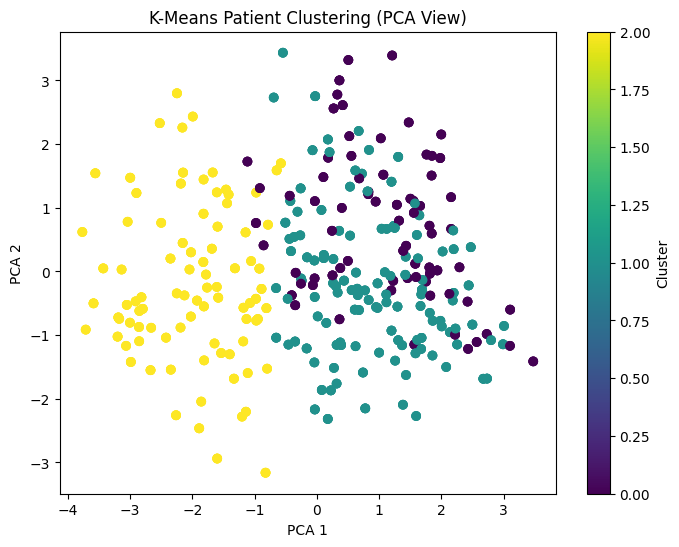

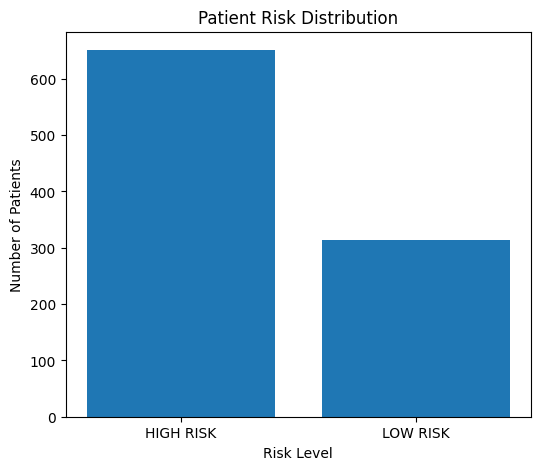

In [12]:
# ==========================================================
# K-MEANS CLUSTERING FOR HEART DISEASE DATASET
# PATIENT GROUPING + RISK CATEGORIZATION + PATTERN DISCOVERY
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ==========================================================
# LOAD DATASET
# ==========================================================

df = pd.read_csv("cleaned_heart.csv")

print("Dataset Shape:", df.shape)

# ==========================================================
# FEATURES (REMOVE TARGET FOR UNSUPERVISED LEARNING)
# ==========================================================

X = df.drop("target", axis=1)

# ==========================================================
# STANDARDIZE DATA
# ==========================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================================
# APPLY K-MEANS CLUSTERING
# ==========================================================

kmeans = KMeans(
    n_clusters=3,   # 3 groups: low, medium, high risk
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataset
df["Cluster"] = clusters

# ==========================================================
# PATIENT GROUPING RESULT
# ==========================================================

print("\n========== PATIENT GROUPING ==========")
print(df["Cluster"].value_counts())

print("\nSample Data with Clusters:")
print(df.head())

# ==========================================================
# RISK CATEGORIZATION (INTERPRET CLUSTERS)
# ==========================================================

# Calculate cluster means
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)

print("\n========== CLUSTER ANALYSIS ==========")
print(cluster_summary)

# Assign risk labels manually based on heart disease target mean
risk_map = {}

for cluster in cluster_summary.index:

    avg_target = df[df["Cluster"] == cluster]["target"].mean()

    if avg_target < 0.3:
        risk_map[cluster] = "LOW RISK"

    elif avg_target < 0.6:
        risk_map[cluster] = "MEDIUM RISK"

    else:
        risk_map[cluster] = "HIGH RISK"

df["Risk_Level"] = df["Cluster"].map(risk_map)

print("\n========== RISK CATEGORIZATION ==========")
print(df[["Cluster", "Risk_Level"]].head())

# ==========================================================
# MEDICAL PATTERN DISCOVERY
# ==========================================================

print("\n========== MEDICAL PATTERN DISCOVERY ==========")

for cluster in sorted(df["Cluster"].unique()):

    print(f"\nCluster {cluster} Patterns:")

    cluster_data = df[df["Cluster"] == cluster]

    print("Average Age:", cluster_data["age"].mean())
    print("Average Cholesterol:", cluster_data["chol"].mean())
    print("Average Heart Rate:", cluster_data["thalach"].mean())
    print("Heart Disease Rate:", cluster_data["target"].mean())

# ==========================================================
# VISUALIZATION USING PCA (2D PLOT)
# ==========================================================

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap='viridis'
)

plt.title("K-Means Patient Clustering (PCA View)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.colorbar(label="Cluster")

plt.show()

# ==========================================================
# RISK DISTRIBUTION GRAPH
# ==========================================================

risk_counts = df["Risk_Level"].value_counts()

plt.figure(figsize=(6,5))

plt.bar(risk_counts.index, risk_counts.values)

plt.title("Patient Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Patients")

plt.show()


MODEL COMPARISON RESULTS
Logistic Regression Accuracy: 85.49 %
K-Means Accuracy: 80.31 %

BEST MODEL: Logistic Regression ✔


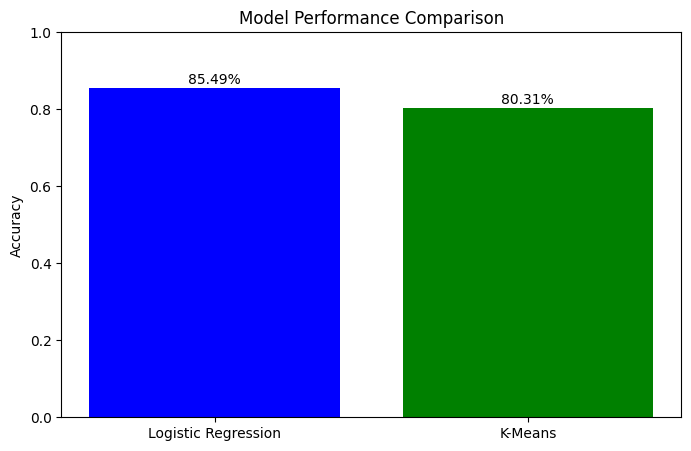

In [25]:
# ==========================================================
# LOGISTIC REGRESSION vs K-MEANS COMPARISON
# HEART DISEASE DATASET
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix

# ==========================================================
# LOAD DATASET
# ==========================================================

df = pd.read_csv("cleaned_heart.csv")

X = df.drop("target", axis=1)
y = df["target"]

# ==========================================================
# SCALE DATA
# ==========================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================================
# TRAIN-TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================================================
# 1. LOGISTIC REGRESSION
# ==========================================================

log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

log_accuracy = accuracy_score(y_test, log_pred)

# ==========================================================
# 2. K-MEANS CLUSTERING
# ==========================================================

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_train)

kmeans_pred = kmeans.predict(X_test)

# ==========================================================
# FIX CLUSTER LABELS (IMPORTANT)
# ==========================================================

# Align clusters with real labels
cm = confusion_matrix(y_test, kmeans_pred)

if cm[0][0] + cm[1][1] < cm[0][1] + cm[1][0]:
    kmeans_pred = 1 - kmeans_pred

kmeans_accuracy = accuracy_score(y_test, kmeans_pred)

# ==========================================================
# PRINT RESULTS
# ==========================================================

print("\n==============================")
print("MODEL COMPARISON RESULTS")
print("==============================")

print("Logistic Regression Accuracy:", round(log_accuracy * 100, 2), "%")
print("K-Means Accuracy:", round(kmeans_accuracy * 100, 2), "%")

# ==========================================================
# BEST MODEL SELECTION
# ==========================================================

if log_accuracy > kmeans_accuracy:
    print("\nBEST MODEL: Logistic Regression ✔")
else:
    print("\nBEST MODEL: K-Means ✔")

# ==========================================================
# VISUAL COMPARISON GRAPH
# ==========================================================

models = ["Logistic Regression", "K-Means"]
accuracies = [log_accuracy, kmeans_accuracy]

plt.figure(figsize=(8,5))

plt.bar(models, accuracies, color=['blue', 'green'])

plt.title("Model Performance Comparison")
plt.ylabel("Accuracy")

# Show values on bars
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v*100:.2f}%", ha='center')

plt.ylim(0, 1)

plt.show()